# Machine Learning - Final Project - Diabetic Classification
## Preprocessing
### John Chester

## Downloading the Data

In [35]:
import os
from pathlib import Path

_DATA_DIR = Path("data")
_DATA_DIR.mkdir(exist_ok=True)

_required = [_DATA_DIR / "2015.csv", _DATA_DIR / "2015_formats.json"]

if not all(f.exists() for f in _required):
    # Requires kaggle CLI configured with ~/.kaggle/kaggle.json
    # Dataset: https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system
    os.system(
        "kaggle datasets download "
        "-d cdc/behavioral-risk-factor-surveillance-system "
        f"-p {_DATA_DIR} --unzip"
    )
    missing = [f.name for f in _required if not f.exists()]
    if missing:
        raise FileNotFoundError(f"Download failed — still missing: {missing}")
    print("Dataset downloaded successfully.")
else:
    print("Dataset already present — skipping download.")

Dataset already present — skipping download.


## EDA

## Step 1 — Data Loading & Initial Audit

In [36]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_CSV  = DATA_DIR / "2015.csv"
CODEBOOK = DATA_DIR / "2015_formats.json"

In [37]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)

with open(CODEBOOK) as f:
    codebook = json.load(f)

print(f"Shape          : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory usage   : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nDtype breakdown:")
print(df_raw.dtypes.value_counts().to_string())

Shape          : 441,456 rows x 330 columns
Memory usage   : 1182.1 MB

Dtype breakdown:
float64    323
str          7


### 1a — Byte-encoded columns & IDATE parsing

BRFSS stores `IDATE` (interview date) as a byte string (`b'MMDDYYYY'`). It is not a health feature and will not be used in modeling, but the byte-string encoding needs to be resolved before column dropping so pandas doesn't carry object-dtype noise forward. We strip the encoding and drop the column entirely.

In [38]:
# Identify all object-dtype columns and flag byte-encoded ones
obj_cols = df_raw.select_dtypes(include="object").columns.tolist()
byte_cols = [
    c for c in obj_cols
    if df_raw[c].dropna().astype(str).str.startswith("b'").any()
]
print(f"Object columns  : {len(obj_cols)}")
print(f"Byte-encoded    : {byte_cols}")

# Drop IDATE entirely — interview date has no health relevance
df_raw.drop(columns=["IDATE"], inplace=True)
print("IDATE dropped.")

Object columns  : 7
Byte-encoded    : ['IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'PCDMDECN', 'EXACTOT1', 'EXACTOT2']
IDATE dropped.


/var/folders/js/tqvb2m154v73xsdw47trh9xh0000gn/T/ipykernel_17735/1284027469.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df_raw.select_dtypes(include="object").columns.tolist()


### 1b — Missing value overview (all 330 columns)

Before selecting the most useful features, we evaluate each feature's amount of missing data, set invalid codes to NaN, and make visualizations.

Columns with any missing : 244 / 329
Columns fully complete   : 85

Top 20 most incomplete columns:
          null_count  null_pct
QLHLTH2       441456    100.00
PAINACT2      441456    100.00
QLSTRES2      441456    100.00
QLMENTL2      441456    100.00
COLGHOUS      441411     99.99
LADULT        441411     99.99
ASDRVIST      441144     99.93
ASERVIST      441143     99.93
ASNOSLEP      440999     99.90
ASINHALR      440817     99.86
ASTHMED3      440817     99.86
ASYMPTOM      440815     99.85
ASACTLIM      440812     99.85
ASRCHKUP      440812     99.85
ASATTACK      440808     99.85
STREHAB1      440762     99.84
PCPSADE1      440637     99.81
HAREHAB1      440445     99.77
ASTHMAGE      440433     99.77
VINOCRE2      440388     99.76


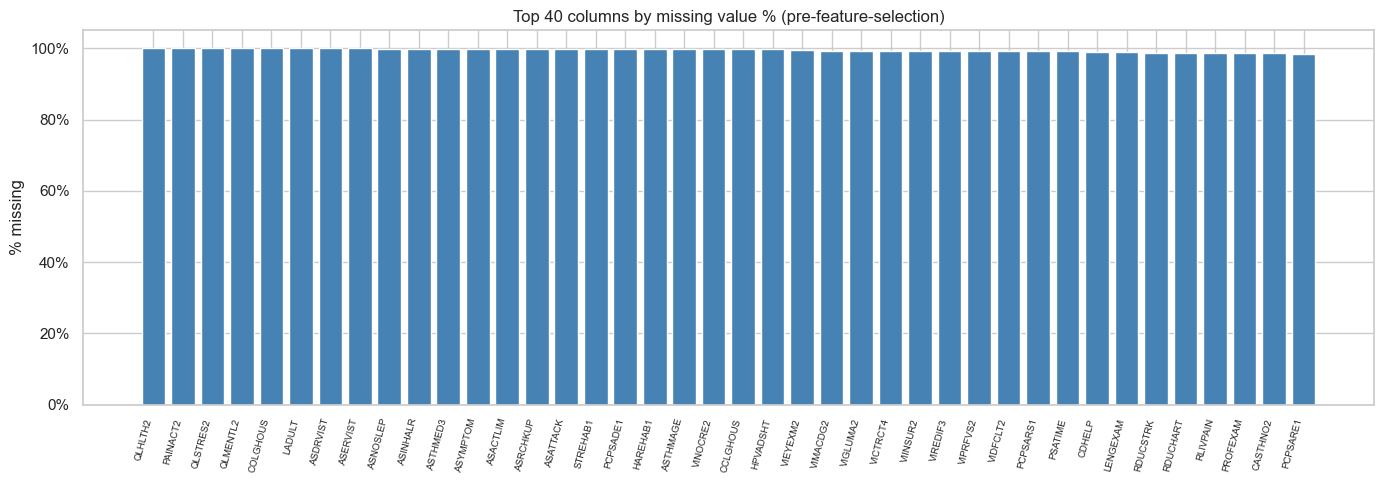

In [39]:
null_counts = df_raw.isnull().sum()
null_pct    = null_counts / len(df_raw) * 100

missing_summary = (
    pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
    .query("null_count > 0")
    .sort_values("null_pct", ascending=False)
)

print(f"Columns with any missing : {len(missing_summary)} / {df_raw.shape[1]}")
print(f"Columns fully complete   : {df_raw.shape[1] - len(missing_summary)}")
print(f"\nTop 20 most incomplete columns:")
print(missing_summary.head(20).to_string())

# Bar chart — top 40 columns by missingness %
top_missing = missing_summary.head(40)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top_missing)), top_missing["null_pct"], color="steelblue", edgecolor="white")
ax.set_xticks(range(len(top_missing)))
ax.set_xticklabels(top_missing.index, rotation=75, ha="right", fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Top 40 columns by missing value % (pre-feature-selection)", fontsize=12)
ax.set_ylabel("% missing")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_missing_values.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "01_missing_values.pdf", bbox_inches="tight", dpi=300)
plt.show()

---
## Step 2 — Feature Selection

Feature selection is grounded in published diabetes research. The CDC's BRFSS has been used extensively in T2D prediction studies which consistently identify the following domains as predictive: metabolic markers (BMI, blood pressure, cholesterol), lifestyle factors (physical activity, diet, smoking, alcohol), chronic comorbidities (stroke, heart disease), healthcare access, self-reported health status, and demographics (age, sex, income, education).

We retain the target `DIABETE3` and 21 clinically recommended features. All administrative columns are dropped.

| BRFSS Column | Feature Name | Rationale |
|---|---|---|
| `DIABETE3` | Target | Diabetes diagnosis (3-class) |
| `_RFHYPE5` | HighBP | High blood pressure is a leading T2D comorbidity |
| `TOLDHI2` | HighChol | High cholesterol is an excellent predictor |
| `_CHOLCHK` | CholCheck | Recent screening indicates healthcare engagement and earlier detection |
| `_BMI5` | BMI | Obesity is the single strongest modifiable risk factor |
| `SMOKE100` | Smoker | Smoking increases insulin resistance and fat accumulation |
| `CVDSTRK3` | Stroke | Stroke and T2D share vascular and inflammatory risk |
| `_MICHD` | HeartDiseaseorAttack | Strongly correlated with undiagnosed or poorly controlled T2D |
| `_TOTINDA` | PhysActivity | Sedentary behavior drives insulin resistance; exercise is a primary prevention tool |
| `_FRTLT1` | Fruits | Low fruit intake is a diet quality marker linked to T2D risk |
| `_VEGLT1` | Veggies | Low vegetable intake correlates with high glycemic index dietary patterns |
| `_RFDRHV5` | HvyAlcoholConsump | Heavy drinking disrupts glucose regulation and liver insulin sensitivity |
| `HLTHPLN1` | AnyHealthcare | Insurance coverage affects screening rates and diagnosis likelihood |
| `MEDCOST` | NoDocbcCost | Social determinant of late T2D diagnosis |
| `GENHLTH` | GenHlth | Self-rated health is a robust predictor of chronic disease |
| `MENTHLTH` | MentHlth | Depression and anxiety are linked to T2D |
| `PHYSHLTH` | PhysHlth | Poor physical health reflects overall likelihood of chronic disease |
| `DIFFWALK` | DiffWalk | Mobility difficulty is associated with obesity, neuropathy, and advanced T2D |
| `SEX` | Sex | T2D prevalence varies by sex |
| `_AGEG5YR` | Age | Age is the strongest T2D risk factor an individual can't change; risk accelerates after 45 |
| `EDUCA` | Education | Education level shapes health literacy, diet, and preventive care access |
| `INCOME2` | Income | Income determines access to healthy food, care, and physical activity infrastructure |

In [40]:
SELECTED_COLS = [
    # Target
    "DIABETE3",
    # Cardiovascular / metabolic
    "_RFHYPE5",   # HighBP
    "TOLDHI2",    # HighChol
    "_CHOLCHK",   # CholCheck
    "_BMI5",      # BMI
    # Lifestyle
    "SMOKE100",   # Smoker
    "_TOTINDA",   # PhysActivity
    "_FRTLT1",    # Fruits
    "_VEGLT1",    # Veggies
    "_RFDRHV5",   # HvyAlcoholConsump
    # Chronic conditions
    "CVDSTRK3",   # Stroke
    "_MICHD",     # HeartDiseaseorAttack
    # Healthcare access
    "HLTHPLN1",   # AnyHealthcare
    "MEDCOST",    # NoDocbcCost
    # Health status
    "GENHLTH",    # GenHlth
    "MENTHLTH",   # MentHlth
    "PHYSHLTH",   # PhysHlth
    "DIFFWALK",   # DiffWalk
    # Demographics
    "SEX",        # Sex
    "_AGEG5YR",   # Age
    "EDUCA",      # Education
    "INCOME2",    # Income
]

# Verify all columns are present before dropping
missing_cols = [c for c in SELECTED_COLS if c not in df_raw.columns]
if missing_cols:
    print(f"WARNING — columns not found: {missing_cols}")
else:
    print("All selected columns confirmed present.")

before = df_raw.shape
df = df_raw[SELECTED_COLS].copy()
after = df.shape

print(f"\nShape before selection : {before[0]:,} rows x {before[1]} columns")
print(f"Shape after selection  : {after[0]:,} rows x {after[1]} columns")
print(f"Columns dropped        : {before[1] - after[1]}")
print(f"\nRetained columns:")
print(df.columns.tolist())

All selected columns confirmed present.

Shape before selection : 441,456 rows x 329 columns
Shape after selection  : 441,456 rows x 22 columns
Columns dropped        : 307

Retained columns:
['DIABETE3', '_RFHYPE5', 'TOLDHI2', '_CHOLCHK', '_BMI5', 'SMOKE100', '_TOTINDA', '_FRTLT1', '_VEGLT1', '_RFDRHV5', 'CVDSTRK3', '_MICHD', 'HLTHPLN1', 'MEDCOST', 'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'DIFFWALK', 'SEX', '_AGEG5YR', 'EDUCA', 'INCOME2']


### 2a — Feature Relevance (pre-cleaning)

We compute the Pearson correlation of each feature against a rough binary version of the target. DIABETE3 responses of 1 (yes, diabetes) are coded as 1; responses of 2 or 3 (no / only during pregnancy) are coded as 0. Uncertain responses (7, 9) and pre-diabetes (4) are excluded from this calculation only — they are retained in the dataset and handled properly in Steps 4-5.

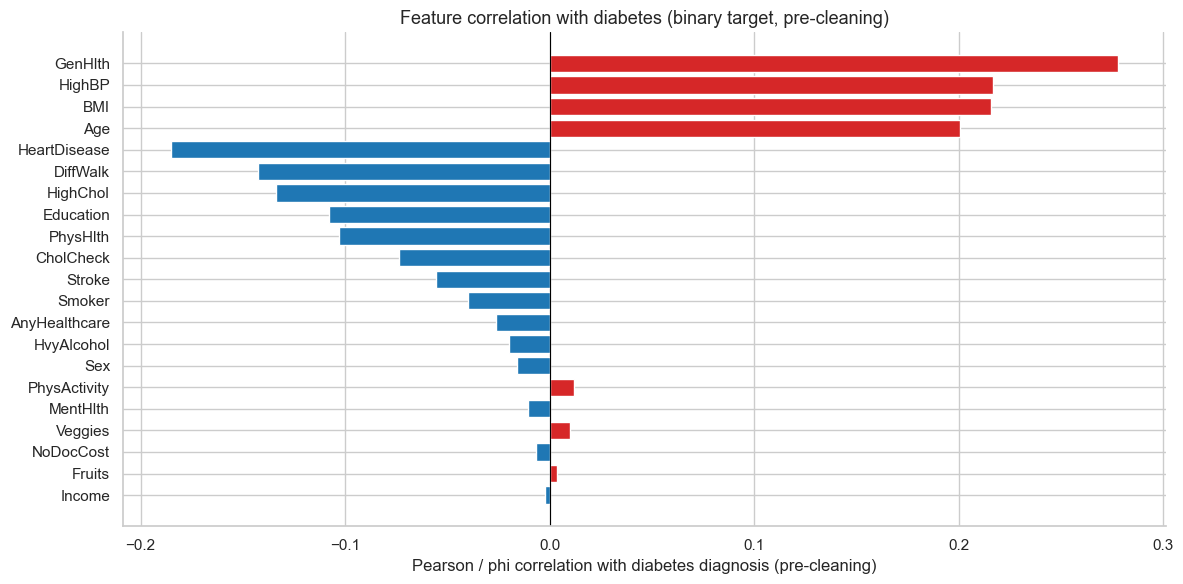


Correlation values (sorted by absolute magnitude):
GenHlth          0.28
HighBP           0.22
BMI              0.22
Age              0.20
HeartDisease    -0.19
DiffWalk        -0.14
HighChol        -0.13
Education       -0.11
PhysHlth        -0.10
CholCheck       -0.07
Stroke          -0.06
Smoker          -0.04
AnyHealthcare   -0.03
HvyAlcohol      -0.02
Sex             -0.02
PhysActivity     0.01
MentHlth        -0.01
Veggies          0.01
NoDocCost       -0.01
Fruits           0.00
Income          -0.00


In [41]:
# Rough binary target for correlation purposes only — not used downstream
_target_map = {1: 1, 2: 0, 3: 0}
_y = df["DIABETE3"].map(_target_map)  # NaN for codes 4, 7, 9

FEATURE_COLS = [c for c in SELECTED_COLS if c != "DIABETE3"]

corr_vals = (
    df[FEATURE_COLS]
    .corrwith(_y, drop=True)
    .dropna()
    .sort_values(key=abs, ascending=False)
)

DISPLAY_NAMES = {
    "_RFHYPE5": "HighBP", "TOLDHI2": "HighChol", "_CHOLCHK": "CholCheck",
    "_BMI5": "BMI", "SMOKE100": "Smoker", "_TOTINDA": "PhysActivity",
    "_FRTLT1": "Fruits", "_VEGLT1": "Veggies", "_RFDRHV5": "HvyAlcohol",
    "CVDSTRK3": "Stroke", "_MICHD": "HeartDisease", "HLTHPLN1": "AnyHealthcare",
    "MEDCOST": "NoDocCost", "GENHLTH": "GenHlth", "MENTHLTH": "MentHlth",
    "PHYSHLTH": "PhysHlth", "DIFFWALK": "DiffWalk", "SEX": "Sex",
    "_AGEG5YR": "Age", "EDUCA": "Education", "INCOME2": "Income",
}
corr_vals.index = corr_vals.index.map(lambda c: DISPLAY_NAMES.get(c, c))

colors = ["#d62728" if v > 0 else "#1f77b4" for v in corr_vals]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(corr_vals.index[::-1], corr_vals.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson / phi correlation with diabetes diagnosis (pre-cleaning)")
ax.set_title("Feature correlation with diabetes (binary target, pre-cleaning)", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_feature_correlation_precleaning.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "02_feature_correlation_precleaning.pdf", bbox_inches="tight", dpi=300)
plt.show()

print("\nCorrelation values (sorted by absolute magnitude):")
print(corr_vals.round(4).to_string())

In [ ]:
# Human-readable labels for every feature's raw survey codes
CODE_LABELS = {
    "_RFHYPE5":  {1: "No HBP", 2: "Has HBP", 9: "DK/Ref"},
    "TOLDHI2":   {1: "Yes", 2: "No", 7: "DK", 9: "Refused"},
    "_CHOLCHK":  {1: "Checked <5yr", 2: "Not checked >5yr", 3: "Never checked", 9: "DK/Ref"},
    "SMOKE100":  {1: "Yes", 2: "No", 7: "DK", 9: "Refused"},
    "CVDSTRK3":  {1: "Yes", 2: "No", 7: "DK", 9: "Refused"},
    "_MICHD":    {1: "Yes", 2: "No"},
    "_TOTINDA":  {1: "Active", 2: "Inactive", 9: "DK/Ref"},
    "_FRTLT1":   {1: "≥1/day", 2: "<1/day", 9: "DK/Ref"},
    "_VEGLT1":   {1: "≥1/day", 2: "<1/day", 9: "DK/Ref"},
    "_RFDRHV5":  {1: "No", 2: "Heavy drinker", 9: "DK/Ref"},
    "HLTHPLN1":  {1: "Has coverage", 2: "No coverage", 7: "DK", 9: "Refused"},
    "MEDCOST":   {1: "Yes (cost barrier)", 2: "No barrier", 7: "DK", 9: "Refused"},
    "GENHLTH":   {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor", 7: "DK", 9: "Refused"},
    "DIFFWALK":  {1: "Yes", 2: "No", 7: "DK", 9: "Refused"},
    "SEX":       {1: "Male", 2: "Female"},
    "_AGEG5YR":  {1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
                  6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
                  11: "70-74", 12: "75-79", 13: "80+", 14: "DK/Ref"},
    "EDUCA":     {1: "No schooling", 2: "Elementary", 3: "Some HS",
                  4: "HS grad", 5: "Some college", 6: "College grad", 9: "Refused"},
    "INCOME2":   {1: "<$10K", 2: "$10-15K", 3: "$15-20K", 4: "$20-25K",
                  5: "$25-35K", 6: "$35-50K", 7: "$50-75K", 8: "$75K+",
                  77: "DK", 99: "Refused"},
}

# Continuous features — bin rather than plot every unique value.
# At this stage (Step 2a), _BMI5 is still in raw BRFSS units (actual BMI × 100),
# so thresholds are multiplied by 100 (e.g. 18.5 → 1850).
# MENTHLTH/PHYSHLTH are 0-30 day counts with 88 not yet recoded.
CONTINUOUS_BINS = {
    "_BMI5": {
        "bins":   [0, 1850, 2500, 3000, 99999],
        "labels": ["Underweight\n(<18.5)", "Normal\n(18.5-25)", "Overweight\n(25-30)", "Obese\n(>30)"],
    },
    "MENTHLTH": {
        "bins":   [-1, 0, 7, 14, 30, 77],
        "labels": ["0 days", "1-7", "8-14", "15-30", "DK/Ref (77/99)"],
    },
    "PHYSHLTH": {
        "bins":   [-1, 0, 7, 14, 30, 77],
        "labels": ["0 days", "1-7", "8-14", "15-30", "DK/Ref (77/99)"],
    },
}

# Reverse lookup: display name to raw column name, preserving top_features order
DISPLAY_TO_RAW = {v: k for k, v in DISPLAY_NAMES.items()}
top_features = corr_vals.head(6).index.tolist()
raw_top = [DISPLAY_TO_RAW[disp] for disp in top_features]  # order matches top_features exactly

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, raw_col, disp_name in zip(axes, raw_top, top_features):
    tmp = df[[raw_col]].copy()
    tmp["diabetes"] = _y
    tmp = tmp.dropna()

    if raw_col in CONTINUOUS_BINS:
        cfg = CONTINUOUS_BINS[raw_col]
        tmp["bin"] = pd.cut(tmp[raw_col], bins=cfg["bins"], labels=cfg["labels"])
        rate = tmp.groupby("bin", observed=True)["diabetes"].mean().reset_index()
        rate.columns = ["label", "diabetes_rate"]
    else:
        rate = tmp.groupby(raw_col)["diabetes"].mean().reset_index()
        rate.columns = ["code", "diabetes_rate"]
        label_map = CODE_LABELS.get(raw_col, {})
        rate["label"] = rate["code"].map(lambda x: label_map.get(int(x), str(int(x))))

    ax.bar(rate["label"], rate["diabetes_rate"], color="steelblue", edgecolor="white")
    ax.set_title(disp_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Diabetes rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelsize=8, rotation=25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("Diabetes rate by feature value — top 6 correlates (pre-cleaning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_diabetes_rate_top6.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "06_diabetes_rate_top6.pdf", bbox_inches="tight", dpi=300)
plt.show()


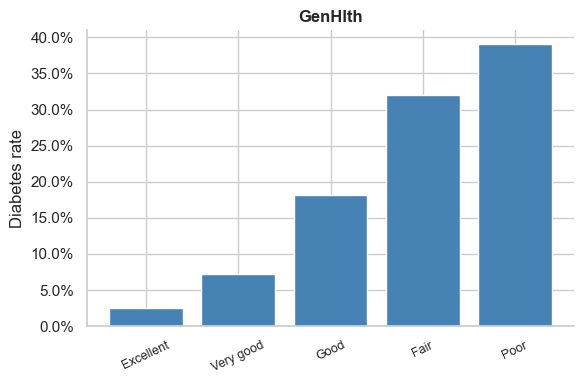

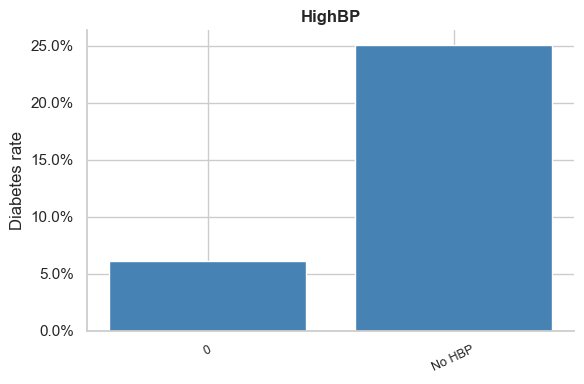

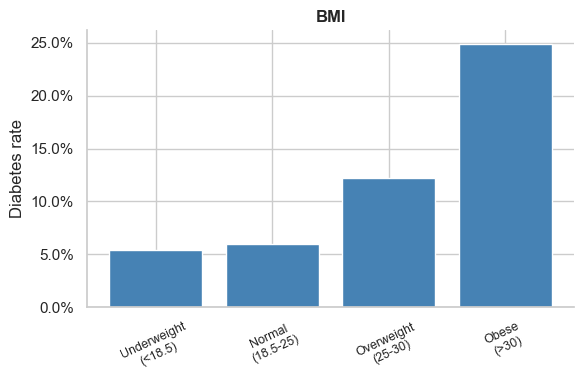

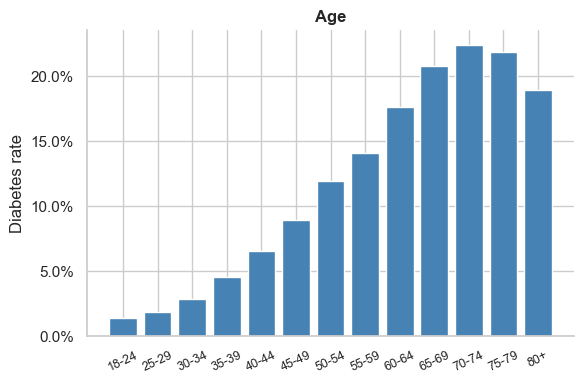

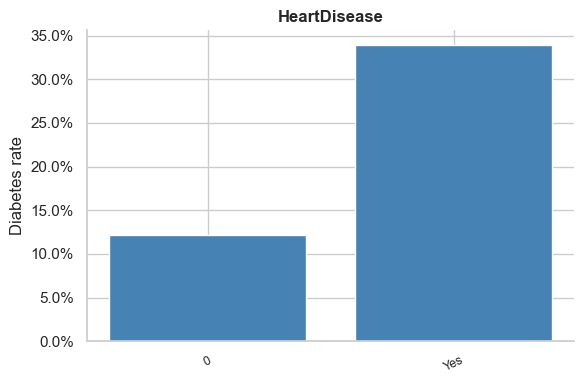

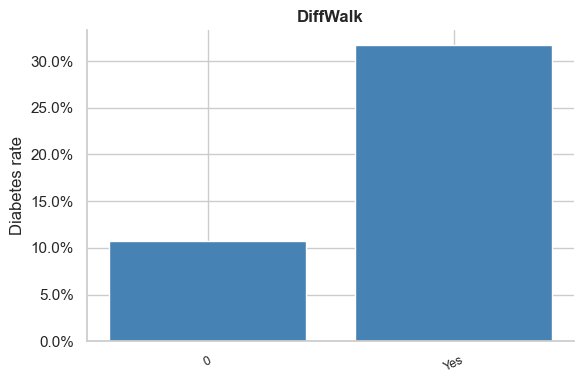

In [63]:
# Individual diabetes-rate plots for each of the top 6 correlate features
FEATURE_FILENAMES = {
    "BMI":      "06a_diabetes_rate_bmi",
    "GenHlth":  "06b_diabetes_rate_genhlth",
    "PhysHlth": "06c_diabetes_rate_physhlth",
    "DiffWalk": "06d_diabetes_rate_diffwalk",
    "Age":      "06e_diabetes_rate_age",
    "MentHlth": "06f_diabetes_rate_menthlth",
}

for raw_col, disp_name in zip(raw_top, top_features):
    fname = FEATURE_FILENAMES.get(disp_name, f"06_{disp_name.lower()}_diabetes_rate")

    tmp = df[[raw_col]].copy()
    tmp["diabetes"] = _y
    tmp = tmp.dropna()

    if raw_col in CONTINUOUS_BINS:
        cfg = CONTINUOUS_BINS[raw_col]
        tmp["bin"] = pd.cut(tmp[raw_col], bins=cfg["bins"], labels=cfg["labels"])
        rate = tmp.groupby("bin", observed=True)["diabetes"].mean().reset_index()
        rate.columns = ["label", "diabetes_rate"]
    else:
        rate = tmp.groupby(raw_col)["diabetes"].mean().reset_index()
        rate.columns = ["code", "diabetes_rate"]
        label_map = CODE_LABELS.get(raw_col, {})
        rate["label"] = rate["code"].map(lambda x: label_map.get(int(x), str(int(x))))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(rate["label"], rate["diabetes_rate"], color="steelblue", edgecolor="white")
    ax.set_title(disp_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Diabetes rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelsize=9, rotation=25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{fname}.png", bbox_inches="tight", dpi=150)
    plt.savefig(OUTPUT_DIR / f"{fname}.pdf", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)


---
## Step 3 — Data Type Fixes & BMI Transformation

Before handling missing/invalid survey codes (Step 4), we fix data types and transform BMI. Critically, BMI sentinel values (BRFSS uses 9999 for refused/missing on `_BMI5`) must be nulled out *before* the divide-by-100 rescaling — otherwise 9999 becomes 99.99, a plausible-looking but invalid value that would survive later cleaning checks.

In [44]:
print("Dtypes before fixes:")
print(df.dtypes.to_string())
print(f"\nUnique _BMI5 values (sample): {sorted(df['_BMI5'].dropna().unique())[:10]} ...")

Dtypes before fixes:
DIABETE3    float64
_RFHYPE5    float64
TOLDHI2     float64
_CHOLCHK    float64
_BMI5       float64
SMOKE100    float64
_TOTINDA    float64
_FRTLT1     float64
_VEGLT1     float64
_RFDRHV5    float64
CVDSTRK3    float64
_MICHD      float64
HLTHPLN1    float64
MEDCOST     float64
GENHLTH     float64
MENTHLTH    float64
PHYSHLTH    float64
DIFFWALK    float64
SEX         float64
_AGEG5YR    float64
EDUCA       float64
INCOME2     float64

Unique _BMI5 values (sample): [np.float64(1202.0), np.float64(1205.0), np.float64(1211.0), np.float64(1215.0), np.float64(1216.0), np.float64(1217.0), np.float64(1220.0), np.float64(1221.0), np.float64(1222.0), np.float64(1233.0)] ...


In [45]:
# Diagnose extreme _BMI5 values in the raw data before any transformation
bmi_raw = df_raw["_BMI5"].dropna()

print("=== _BMI5 raw value distribution ===")
print(f"Total non-null rows : {len(bmi_raw):,}")
print(f"Min                 : {bmi_raw.min()}")
print(f"Max                 : {bmi_raw.max()}")
print(f"\nValue counts above 9000 (potential sentinels):")
print(bmi_raw[bmi_raw > 9000].value_counts().sort_index().to_string())
print(f"\nValue counts above 7500 (extreme BMI ÷100 to >75):")
print(bmi_raw[bmi_raw > 7500].value_counts().sort_index().to_string())

=== _BMI5 raw value distribution ===
Total non-null rows : 405,058
Min                 : 1202.0
Max                 : 9995.0

Value counts above 9000 (potential sentinels):
_BMI5
9089.00     1
9147.00     1
9155.00     1
9182.00    52
9247.00     1
9452.00     1
9466.00    24
9485.00     1
9568.00     1
9654.00     1
9711.00     1
9738.00     1
9765.00    19
9995.00     1

Value counts above 7500 (extreme BMI ÷100 to >75):
_BMI5
7501.00     1
7517.00    59
7526.00     1
7528.00     1
7531.00     1
7537.00    17
7558.00     2
7564.00     1
7600.00     1
7602.00     1
7611.00     1
7612.00     1
7682.00     1
7714.00     1
7724.00    57
7729.00    32
7796.00     1
7802.00     1
7812.00     3
7831.00     1
7879.00     1
7900.00     1
7910.00     2
7923.00     1
7929.00    37
7941.00    76
7942.00     1
7971.00     1
7993.00     1
8013.00     1
8074.00     1
8079.00     1
8119.00     1
8122.00     1
8137.00    86
8139.00     1
8167.00    71
8170.00     1
8176.00     1
8231.00     2
8264.00

In [46]:
# --- BMI: null sentinel (9999 = not asked/missing), then rescale ---
# Only 9999 is a sentinel in _BMI5; all other values including extreme ones are valid computed BMIs
BMI_SENTINEL = 9999
n_bmi_sentinels = (df["_BMI5"] == BMI_SENTINEL).sum()
print(f"BMI sentinel (9999) nulled : {n_bmi_sentinels:,}")

df["_BMI5"] = df["_BMI5"].where(df["_BMI5"] != BMI_SENTINEL)
df["_BMI5"] = (df["_BMI5"] / 100).round(2)

bmi_min, bmi_max = df["_BMI5"].min(), df["_BMI5"].max()
print(f"BMI range after rescaling  : {bmi_min} - {bmi_max}")
print(f"Rows with BMI > 70         : {(df['_BMI5'] > 70).sum():,}  (valid extreme values)")

# --- Cast all feature columns to nullable Int16 ---
# _BMI5 stays float; all others are ordinal/binary codes or 0-30 day counts
FLOAT_TO_INT_COLS = [c for c in df.columns if c != "_BMI5"]

for col in FLOAT_TO_INT_COLS:
    try:
        df[col] = df[col].astype("Int16")
    except (ValueError, TypeError) as e:
        print(f"  Could not cast {col}: {e}")

print("\nDtypes after fixes:")
print(df.dtypes.to_string())

BMI sentinel (9999) nulled : 0
BMI range after rescaling  : 12.02 - 99.95
Rows with BMI > 70         : 1,035  (valid extreme values)

Dtypes after fixes:
DIABETE3      Int16
_RFHYPE5      Int16
TOLDHI2       Int16
_CHOLCHK      Int16
_BMI5       float64
SMOKE100      Int16
_TOTINDA      Int16
_FRTLT1       Int16
_VEGLT1       Int16
_RFDRHV5      Int16
CVDSTRK3      Int16
_MICHD        Int16
HLTHPLN1      Int16
MEDCOST       Int16
GENHLTH       Int16
MENTHLTH      Int16
PHYSHLTH      Int16
DIFFWALK      Int16
SEX           Int16
_AGEG5YR      Int16
EDUCA         Int16
INCOME2       Int16


In [47]:
# Verify no mixed-type or unexpected object columns remain
obj_remaining = df.select_dtypes(include="object").columns.tolist()
if obj_remaining:
    print(f"WARNING — object columns still present: {obj_remaining}")
else:
    print("All columns are numeric — no mixed-type columns remaining.")

print(f"\nShape unchanged: {df.shape}")

All columns are numeric — no mixed-type columns remaining.

Shape unchanged: (441456, 22)


---
## Step 4 — Missing & Invalid Value Handling

BRFSS encodes two types of non-response in addition to structural `NaN`:

| Code pattern | Meaning | Action |
|---|---|---|
| `NaN` | Not asked / structurally missing | Already NaN |
| `7`, `9`, `77`, `99` | Don't know / Refused | >> `NaN` |
| `88` on MENTHLTH / PHYSHLTH | "None" (zero bad days) | >> `0` (valid response, not missing) |

Invalid codes vary by column — we define them explicitly per feature rather than applying a blanket rule, to avoid incorrectly nulling valid ordinal values (e.g., `9` is a valid age bracket code for `_AGEG5YR`).

In [48]:
print(f"Shape before invalid-code recoding : {df.shape[0]:,} rows")
print(f"\nMissing values per feature (before recoding):")
print(df.isnull().sum().to_string())

Shape before invalid-code recoding : 441,456 rows

Missing values per feature (before recoding):
DIABETE3        7
_RFHYPE5        0
TOLDHI2     59154
_CHOLCHK        0
_BMI5       36398
SMOKE100    14255
_TOTINDA        0
_FRTLT1         0
_VEGLT1         0
_RFDRHV5        0
CVDSTRK3        0
_MICHD       3942
HLTHPLN1        0
MEDCOST         1
GENHLTH         2
MENTHLTH        0
PHYSHLTH        1
DIFFWALK    12334
SEX             0
_AGEG5YR        0
EDUCA           0
INCOME2      3301


In [49]:
# Per-feature invalid codes >> NaN
# Defined explicitly to avoid blanket rules that would corrupt valid ordinal values
INVALID_CODES = {
    "DIABETE3":  [7, 9],
    "_RFHYPE5":  [9],
    "TOLDHI2":   [7, 9],
    "_CHOLCHK":  [9],
    "SMOKE100":  [7, 9],
    "_TOTINDA":  [9],
    "_FRTLT1":   [9],
    "_VEGLT1":   [9],
    "_RFDRHV5":  [9],
    "CVDSTRK3":  [7, 9],
    "HLTHPLN1":  [7, 9],
    "MEDCOST":   [7, 9],
    "GENHLTH":   [7, 9],
    "MENTHLTH":  [77, 99],   # 88 = "None" >> recoded to 0 separately below
    "PHYSHLTH":  [77, 99],   # 88 = "None" >> recoded to 0 separately below
    "DIFFWALK":  [7, 9],
    "_AGEG5YR":  [14],       # 9 is valid (age 60-64); only 14 is DK/Refused
    "EDUCA":     [9],
    "INCOME2":   [77, 99],
    # SEX, _MICHD: no invalid codes (fully computed / binary with no DK option)
}

# Recode 88 >> 0 for day-count features before nulling other invalids
for col in ["MENTHLTH", "PHYSHLTH"]:
    n = (df[col] == 88).sum()
    df[col] = df[col].replace({88: 0})
    print(f"{col}: {n:,} rows recoded 88 to 0  (zero bad days)")

# Null all invalid codes
for col, codes in INVALID_CODES.items():
    n = df[col].isin(codes).sum()
    df[col] = df[col].replace({c: pd.NA for c in codes})
    if n > 0:
        print(f"{col}: {n:,} rows to NaN  {codes}")

MENTHLTH: 301,076 rows recoded 88 to 0  (zero bad days)
PHYSHLTH: 274,143 rows recoded 88 to 0  (zero bad days)
DIABETE3: 791 rows to NaN  [7, 9]
_RFHYPE5: 1,367 rows to NaN  [9]
TOLDHI2: 3,561 rows to NaN  [7, 9]
_CHOLCHK: 15,337 rows to NaN  [9]
SMOKE100: 3,294 rows to NaN  [7, 9]
_TOTINDA: 37,992 rows to NaN  [9]
_FRTLT1: 43,711 rows to NaN  [9]
_VEGLT1: 51,117 rows to NaN  [9]
_RFDRHV5: 25,733 rows to NaN  [9]
CVDSTRK3: 1,290 rows to NaN  [7, 9]
HLTHPLN1: 1,840 rows to NaN  [7, 9]
MEDCOST: 1,193 rows to NaN  [7, 9]
GENHLTH: 1,245 rows to NaN  [7, 9]
MENTHLTH: 7,408 rows to NaN  [77, 99]
PHYSHLTH: 9,742 rows to NaN  [77, 99]
DIFFWALK: 2,260 rows to NaN  [7, 9]
_AGEG5YR: 5,336 rows to NaN  [14]
EDUCA: 1,811 rows to NaN  [9]
INCOME2: 76,204 rows to NaN  [77, 99]


Missingness per feature after invalid-code recoding:
          null_count  null_pct
INCOME2        79505     18.01
TOLDHI2        62715     14.21
_VEGLT1        51117     11.58
_FRTLT1        43711      9.90
_TOTINDA       37992      8.61
_BMI5          36398      8.24
_RFDRHV5       25733      5.83
SMOKE100       17549      3.98
_CHOLCHK       15337      3.47
DIFFWALK       14594      3.31
PHYSHLTH        9743      2.21
MENTHLTH        7408      1.68
_AGEG5YR        5336      1.21
_MICHD          3942      0.89
HLTHPLN1        1840      0.42
EDUCA           1811      0.41
_RFHYPE5        1367      0.31
CVDSTRK3        1290      0.29
GENHLTH         1247      0.28
MEDCOST         1194      0.27
DIABETE3         798      0.18
SEX                0      0.00


/var/folders/js/tqvb2m154v73xsdw47trh9xh0000gn/T/ipykernel_17735/2507664421.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing_after.index, rotation=45, ha="right", fontsize=9)


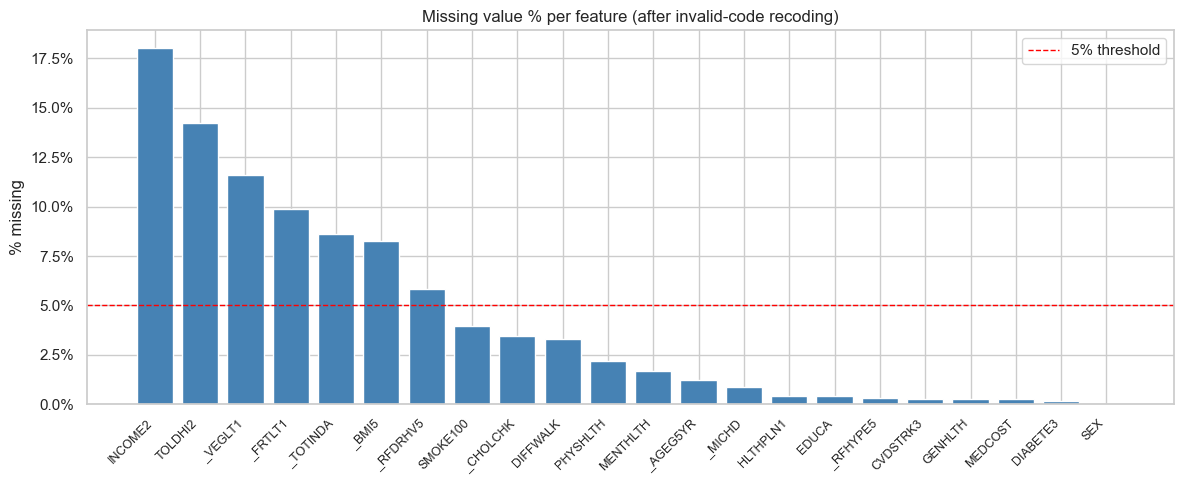

In [50]:
# Missingness per feature after recoding — focused view on our 21 features
null_after = df.isnull().sum()
null_pct_after = null_after / len(df) * 100

missing_after = (
    pd.DataFrame({"null_count": null_after, "null_pct": null_pct_after})
    .sort_values("null_pct", ascending=False)
)

print("Missingness per feature after invalid-code recoding:")
print(missing_after.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(missing_after.index, missing_after["null_pct"], color="steelblue", edgecolor="white")
ax.axhline(5, color="red", linestyle="--", linewidth=1, label="5% threshold")
ax.set_xticklabels(missing_after.index, rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Missing value % per feature (after invalid-code recoding)", fontsize=12)
ax.set_ylabel("% missing")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_missing_after_recoding.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "03_missing_after_recoding.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [51]:
# Drop rows with any remaining NaN across all features
# Given Step 1 showed all features were <1% missing pre-recoding, and the
# invalid codes above add a small additional fraction, total loss should be modest
before_drop = len(df)
df = df.dropna()
after_drop = len(df)

dropped = before_drop - after_drop
print(f"Rows before drop : {before_drop:,}")
print(f"Rows after drop  : {after_drop:,}")
print(f"Rows dropped     : {dropped:,}  ({dropped / before_drop * 100:.2f}%)")
print(f"\nRemaining NaN values: {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "NaN values remain after dropna"
print("Assertion passed — no NaN values remain.")

Rows before drop : 441,456
Rows after drop  : 253,680
Rows dropped     : 187,776  (42.54%)

Remaining NaN values: 0
Assertion passed — no NaN values remain.


---
## Step 5 — Target Variable Construction

We construct two target variants from `DIABETE3`. No resampling is applied here — class balancing happens in Step 9 after the train/test split.

**DIABETE3 raw codes:**
| Code | Meaning | Maps to |
|---|---|---|
| `1` | Yes, diabetes | `Diabetes_012 = 2`, `Diabetes_binary = 1` |
| `2` | No | `Diabetes_012 = 0`, `Diabetes_binary = 0` |
| `3` | No, only during pregnancy | `Diabetes_012 = 0`, `Diabetes_binary = 0` |
| `4` | Pre-diabetes / borderline | `Diabetes_012 = 1`, `Diabetes_binary = 1` |

`Diabetes_binary` merges pre-diabetes and diabetes into a single positive class, reflecting clinical interest in detecting any elevated risk.

In [52]:
DIABETE3_TO_012    = {1: 2, 2: 0, 3: 0, 4: 1}
DIABETE3_TO_BINARY = {1: 1, 2: 0, 3: 0, 4: 1}

df["Diabetes_012"]    = df["DIABETE3"].map(DIABETE3_TO_012).astype("Int8")
df["Diabetes_binary"] = df["DIABETE3"].map(DIABETE3_TO_BINARY).astype("Int8")

# Verify no unmapped codes slipped through
assert df["Diabetes_012"].isna().sum() == 0,    "Unmapped DIABETE3 codes in Diabetes_012"
assert df["Diabetes_binary"].isna().sum() == 0, "Unmapped DIABETE3 codes in Diabetes_binary"

# --- Class distributions ---
def class_dist(series, label):
    counts = series.value_counts().sort_index()
    pcts   = (counts / counts.sum() * 100).round(1)
    summary = pd.DataFrame({"count": counts, "pct": pcts})
    print(f"\n{label}")
    print(summary.to_string())
    print(f"  Imbalance ratio (majority / minority): "
          f"{counts.max() / counts.min():.1f}x")

class_dist(df["Diabetes_012"],    "Diabetes_012    (0=no diabetes, 1=pre-diabetes, 2=diabetes)")
class_dist(df["Diabetes_binary"], "Diabetes_binary (0=no diabetes, 1=pre-diabetes or diabetes)")


Diabetes_012    (0=no diabetes, 1=pre-diabetes, 2=diabetes)
               count   pct
Diabetes_012              
0             213703 84.20
1               4631  1.80
2              35346 13.90
  Imbalance ratio (majority / minority): 46.1x

Diabetes_binary (0=no diabetes, 1=pre-diabetes or diabetes)
                  count   pct
Diabetes_binary              
0                213703 84.20
1                 39977 15.80
  Imbalance ratio (majority / minority): 5.3x


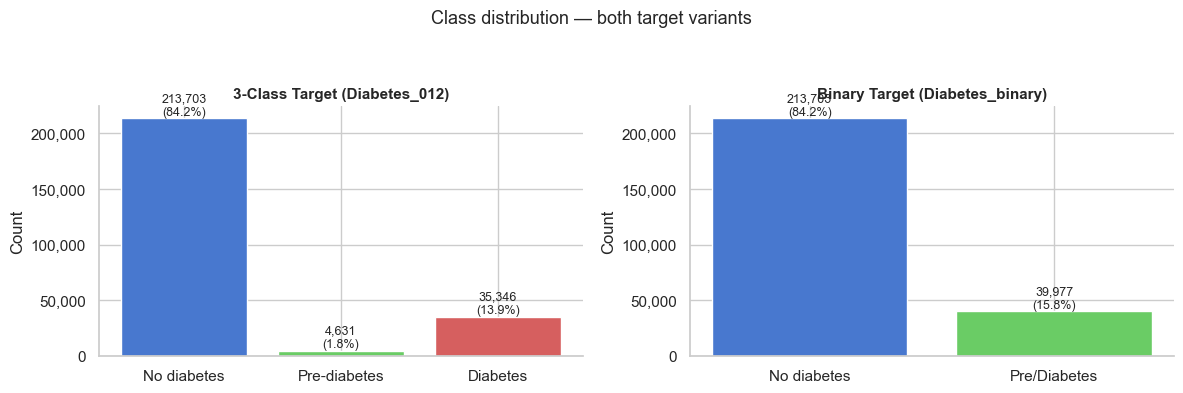

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title, labels in zip(
    axes,
    ["Diabetes_012", "Diabetes_binary"],
    ["3-Class Target (Diabetes_012)", "Binary Target (Diabetes_binary)"],
    [{0: "No diabetes", 1: "Pre-diabetes", 2: "Diabetes"},
     {0: "No diabetes", 1: "Pre/Diabetes"}],
):
    counts = df[col].value_counts().sort_index()
    tick_labels = [labels[k] for k in counts.index]
    bars = ax.bar(tick_labels, counts.values, color=["#4878cf", "#6acc65", "#d65f5f"][:len(counts)],
                  edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f"{val:,}\n({val/len(df)*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("Class distribution — both target variants", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(OUTPUT_DIR / "04_class_distribution.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "04_class_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()

---
## Step 6 — EDA

### 6a — Feature Harmonization

Before visualizing, we recode all binary features from BRFSS's 1/2 encoding to standard 0/1. Ordinal features (GenHlth, Age, Education, Income) and continuous features (BMI, MentHlth, PhysHlth) are left as-is.

In [54]:
# Features where 1=Yes, 2=No. Recode 2 to 0
RECODE_2_TO_0 = [
    "TOLDHI2",   # HighChol:        1=Yes, 2=No
    "SMOKE100",  # Smoker:          1=Yes, 2=No
    "CVDSTRK3",  # Stroke:          1=Yes, 2=No
    "_MICHD",    # HeartDisease:    1=Yes, 2=No
    "_TOTINDA",  # PhysActivity:    1=Active, 2=Inactive
    "_FRTLT1",   # Fruits:          1=≥1/day, 2=<1/day
    "_VEGLT1",   # Veggies:         1=≥1/day, 2=<1/day
    "HLTHPLN1",  # AnyHealthcare:   1=Yes, 2=No
    "MEDCOST",   # NoDocCost:       1=Yes (barrier), 2=No
    "DIFFWALK",  # DiffWalk:        1=Yes, 2=No
]
for col in RECODE_2_TO_0:
    df[col] = df[col].replace({2: 0})

# _RFHYPE5: 1=No HBP, 2=Yes HBP — inverted, flip to 0=No, 1=Yes
df["_RFHYPE5"] = df["_RFHYPE5"].replace({1: 0, 2: 1})

# _RFDRHV5: 1=Not heavy drinker, 2=Heavy drinker — inverted, flip to 0=No, 1=Yes
df["_RFDRHV5"] = df["_RFDRHV5"].replace({1: 0, 2: 1})

# _CHOLCHK: 1=Checked <5yr, 2=Not checked >5yr, 3=Never to 1=Checked, 0=Not checked
df["_CHOLCHK"] = df["_CHOLCHK"].replace({2: 0, 3: 0})

# SEX: 1=Male, 2=Female to 1=Male, 0=Female
df["SEX"] = df["SEX"].replace({2: 0})

# Verify all binary features now contain only 0 and 1
BINARY_COLS = RECODE_2_TO_0 + ["_RFHYPE5", "_RFDRHV5", "_CHOLCHK", "SEX"]
for col in BINARY_COLS:
    vals = set(df[col].dropna().unique())
    unexpected = vals - {0, 1}
    if unexpected:
        print(f"WARNING {col}: unexpected values {unexpected}")

print("Feature harmonization complete.")
print(f"\nBinary features (0/1): {BINARY_COLS}")
print(f"Ordinal features     : GENHLTH, _AGEG5YR, EDUCA, INCOME2")
print(f"Continuous features  : _BMI5, MENTHLTH, PHYSHLTH")

Feature harmonization complete.

Binary features (0/1): ['TOLDHI2', 'SMOKE100', 'CVDSTRK3', '_MICHD', '_TOTINDA', '_FRTLT1', '_VEGLT1', 'HLTHPLN1', 'MEDCOST', 'DIFFWALK', '_RFHYPE5', '_RFDRHV5', '_CHOLCHK', 'SEX']
Ordinal features     : GENHLTH, _AGEG5YR, EDUCA, INCOME2
Continuous features  : _BMI5, MENTHLTH, PHYSHLTH


### 6b — Diabetes Rate by Feature Value

For each of the 21 features we show the diabetes prevalence rate at each possible value. Binary features show two bars (0/1). Ordinal features show one bar per level. Continuous features (BMI, MentHlth, PhysHlth) are binned into clinically meaningful ranges.

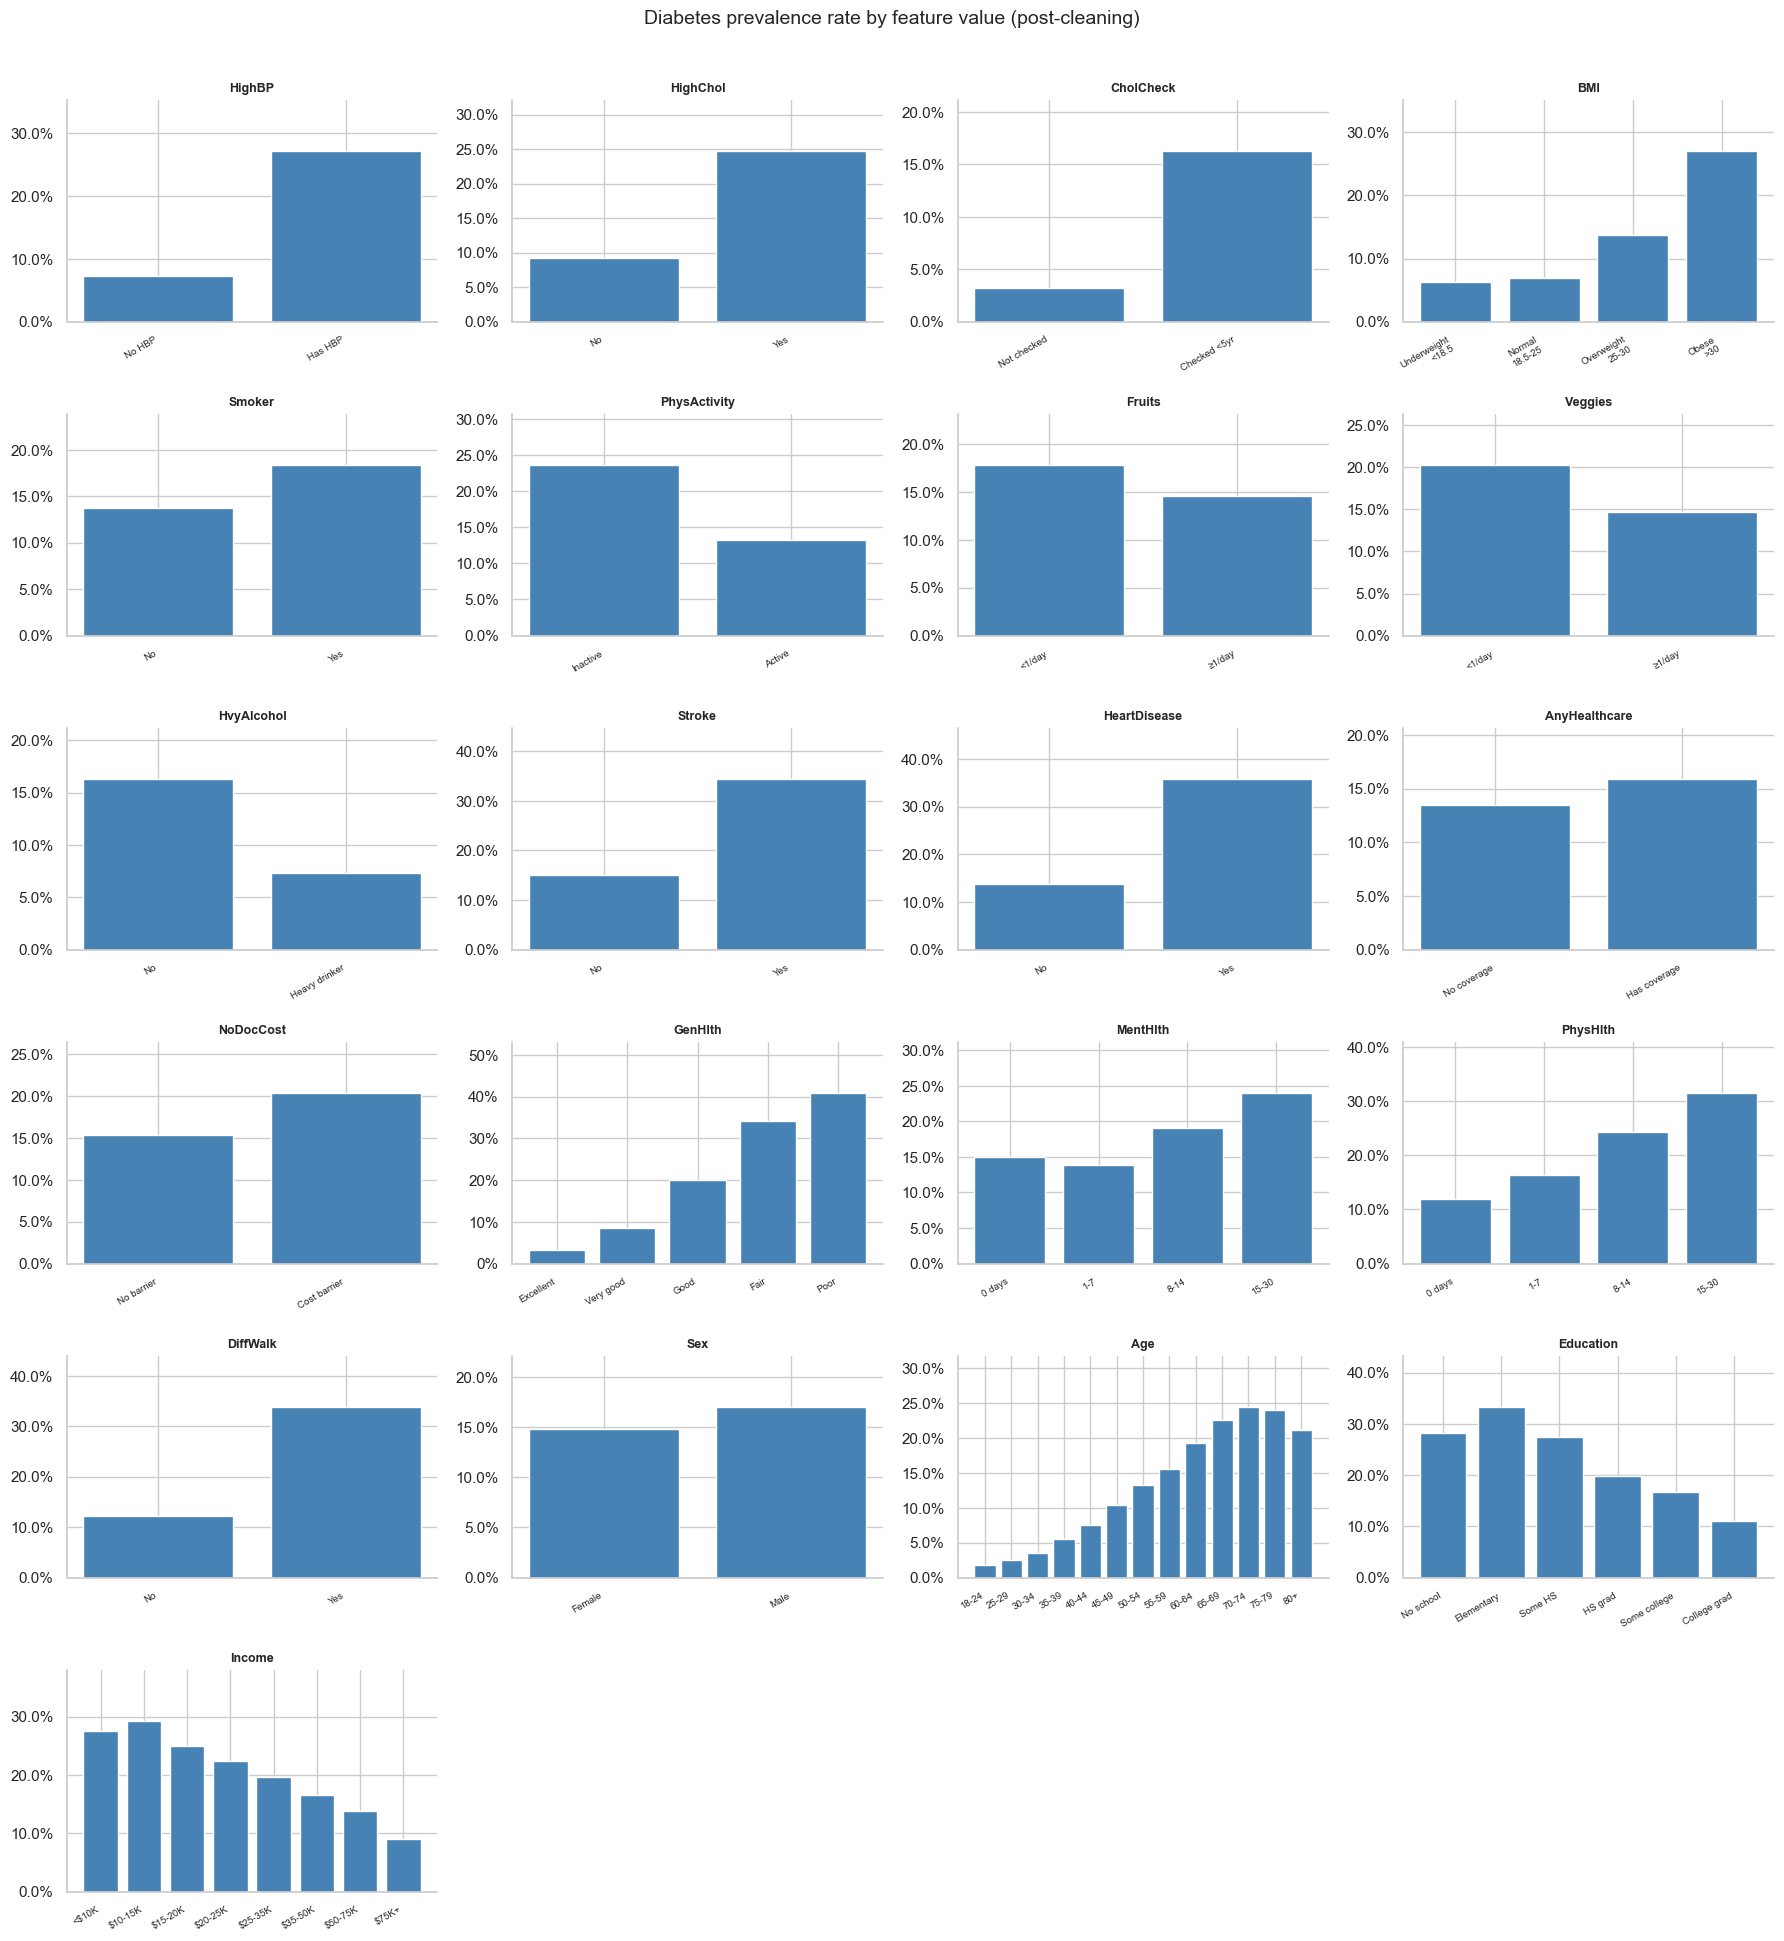

In [55]:
FEATURE_COLS_MODEL = [c for c in SELECTED_COLS if c != "DIABETE3"]

# Post-harmonization label maps (0/1 binary features now use 0=No, 1=Yes)
POST_LABELS = {
    "_RFHYPE5":  {0: "No HBP", 1: "Has HBP"},
    "TOLDHI2":   {0: "No", 1: "Yes"},
    "_CHOLCHK":  {0: "Not checked", 1: "Checked <5yr"},
    "SMOKE100":  {0: "No", 1: "Yes"},
    "CVDSTRK3":  {0: "No", 1: "Yes"},
    "_MICHD":    {0: "No", 1: "Yes"},
    "_TOTINDA":  {0: "Inactive", 1: "Active"},
    "_FRTLT1":   {0: "<1/day", 1: "≥1/day"},
    "_VEGLT1":   {0: "<1/day", 1: "≥1/day"},
    "_RFDRHV5":  {0: "No", 1: "Heavy drinker"},
    "HLTHPLN1":  {0: "No coverage", 1: "Has coverage"},
    "MEDCOST":   {0: "No barrier", 1: "Cost barrier"},
    "DIFFWALK":  {0: "No", 1: "Yes"},
    "SEX":       {0: "Female", 1: "Male"},
    "GENHLTH":   {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"},
    "_AGEG5YR":  {1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
                  6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
                  11: "70-74", 12: "75-79", 13: "80+"},
    "EDUCA":     {1: "No school", 2: "Elementary", 3: "Some HS",
                  4: "HS grad", 5: "Some college", 6: "College grad"},
    "INCOME2":   {1: "<$10K", 2: "$10-15K", 3: "$15-20K", 4: "$20-25K",
                  5: "$25-35K", 6: "$35-50K", 7: "$50-75K", 8: "$75K+"},
}

CONT_BINS_CLEAN = {
    "_BMI5":    {"bins": [0, 18.5, 25, 30, 100], "labels": ["Underweight\n<18.5", "Normal\n18.5-25", "Overweight\n25-30", "Obese\n>30"]},
    "MENTHLTH": {"bins": [-1, 0, 7, 14, 30],     "labels": ["0 days", "1-7", "8-14", "15-30"]},
    "PHYSHLTH": {"bins": [-1, 0, 7, 14, 30],     "labels": ["0 days", "1-7", "8-14", "15-30"]},
}

ncols = 4
nrows = -(-len(FEATURE_COLS_MODEL) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS_MODEL):
    tmp = df[[col, "Diabetes_binary"]].copy().dropna()

    if col in CONT_BINS_CLEAN:
        cfg = CONT_BINS_CLEAN[col]
        tmp["grp"] = pd.cut(tmp[col], bins=cfg["bins"], labels=cfg["labels"])
        rate = tmp.groupby("grp", observed=True)["Diabetes_binary"].mean()
        xlabels = rate.index.tolist()
    else:
        rate = tmp.groupby(col)["Diabetes_binary"].mean()
        lmap = POST_LABELS.get(col, {})
        xlabels = [lmap.get(int(k), str(int(k))) for k in rate.index]

    ax.bar(range(len(rate)), rate.values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(xlabels, fontsize=7, rotation=30, ha="right")
    ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=9, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, min(rate.max() * 1.3, 1))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Hide unused axes
for ax in axes[len(FEATURE_COLS_MODEL):]:
    ax.set_visible(False)

plt.suptitle("Diabetes prevalence rate by feature value (post-cleaning)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_diabetes_rate_all_features.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "07_diabetes_rate_all_features.pdf", bbox_inches="tight", dpi=300)
plt.show()

### 6c — Correlation Matrix

Pearson correlations across all 21 features and `Diabetes_binary`. For binary features this is technically the phi coefficient — valid but bounded by marginal distributions, so values rarely approach ±1 even for strong associations.

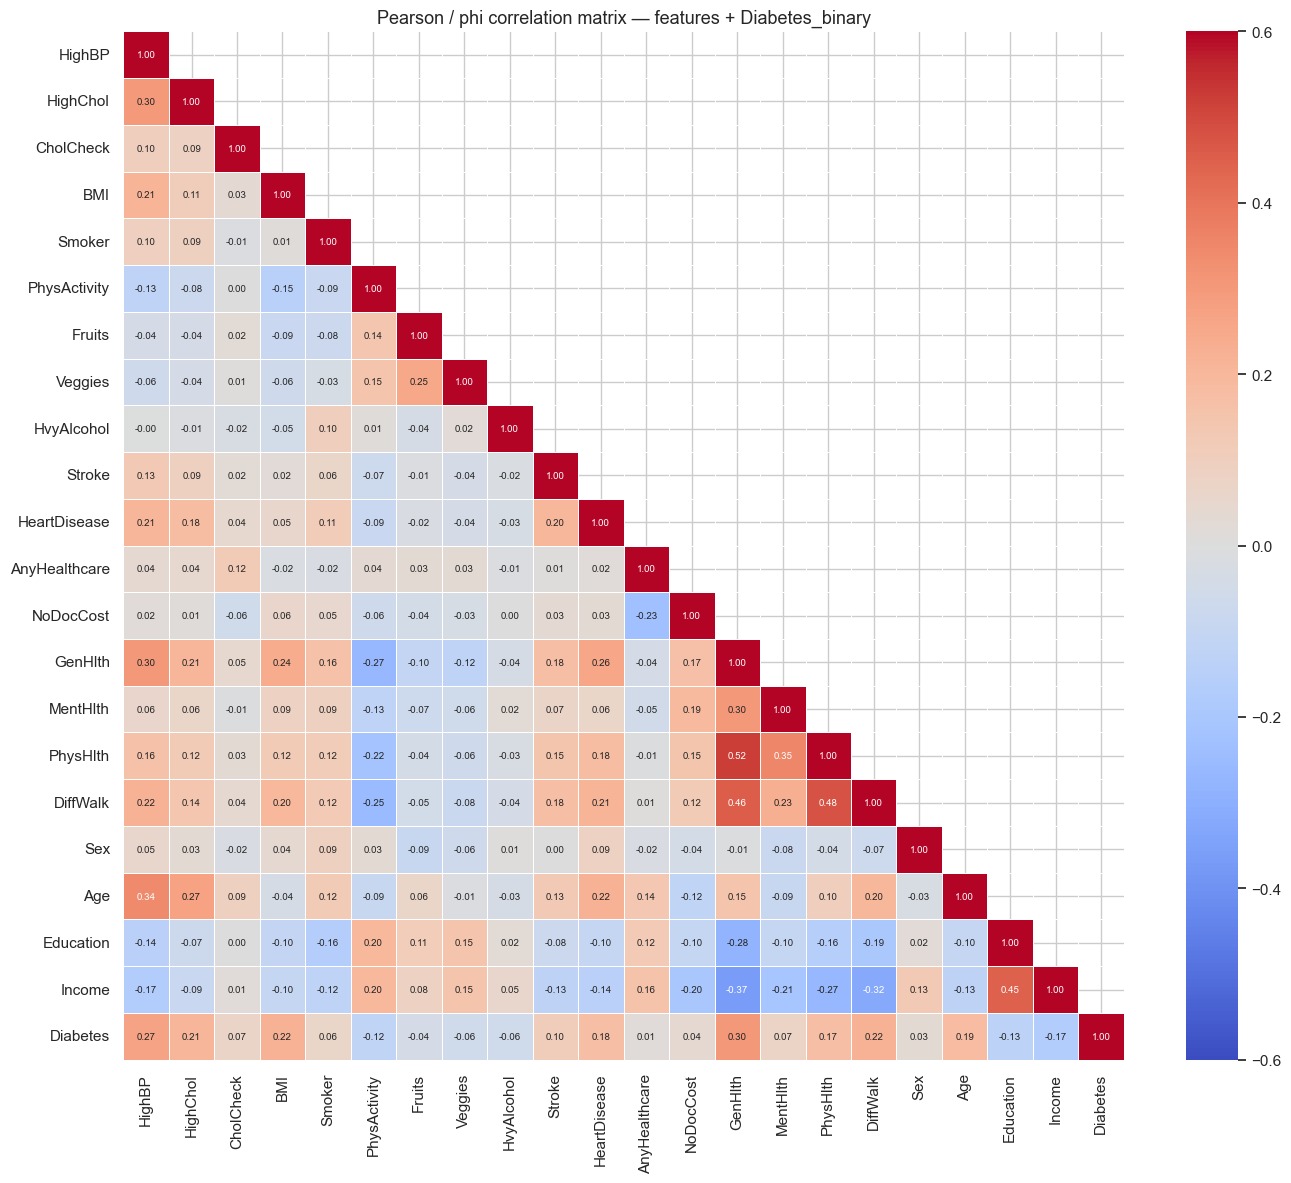

In [56]:
corr_cols = FEATURE_COLS_MODEL + ["Diabetes_binary"]
corr_df = df[corr_cols].astype(float).corr()

# Rename for readability
rename_map = {**DISPLAY_NAMES, "Diabetes_binary": "Diabetes"}
corr_df = corr_df.rename(index=rename_map, columns=rename_map)

mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-0.6, vmax=0.6, linewidths=0.4,
    annot_kws={"size": 7}, ax=ax
)
ax.set_title("Pearson / phi correlation matrix — features + Diabetes_binary", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_correlation_matrix.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "08_correlation_matrix.pdf", bbox_inches="tight", dpi=300)
plt.show()

### 6d — BMI Distribution by Diabetes Status

BMI is the single strongest modifiable T2D risk factor. We show overlapping KDE curves split by diabetes class, with clinical threshold lines marking the WHO BMI categories.

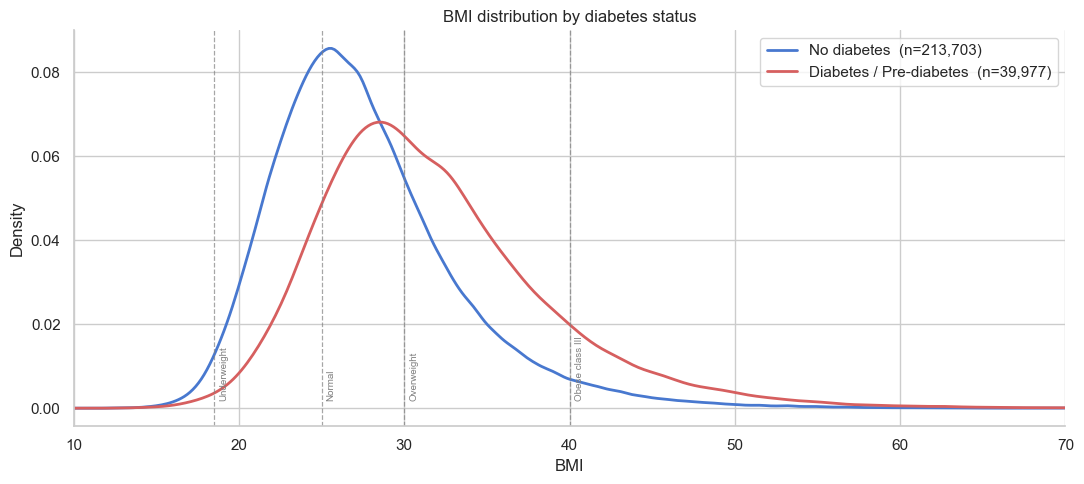

Median BMI — No diabetes       : 26.6
Median BMI — Diabetes/Pre-diab : 30.7


In [57]:
fig, ax = plt.subplots(figsize=(11, 5))

for label, color, val in [(0, "#4878cf", "No diabetes"), (1, "#d65f5f", "Diabetes / Pre-diabetes")]:
    subset = df.loc[df["Diabetes_binary"] == label, "_BMI5"].dropna()
    subset.plot.kde(ax=ax, label=f"{val}  (n={len(subset):,})", color=color, linewidth=2)

for threshold, name in [(18.5, "Underweight"), (25, "Normal"), (30, "Overweight"), (40, "Obese class III")]:
    ax.axvline(threshold, color="grey", linestyle="--", linewidth=0.9, alpha=0.7)
    ax.text(threshold + 0.3, ax.get_ylim()[1] * 0.02, name, fontsize=7, color="grey", rotation=90, va="bottom")

ax.set_xlim(10, 70)
ax.set_xlabel("BMI")
ax.set_ylabel("Density")
ax.set_title("BMI distribution by diabetes status", fontsize=12)
ax.legend()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_bmi_distribution.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "09_bmi_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()

print(f"Median BMI — No diabetes       : {df.loc[df['Diabetes_binary']==0, '_BMI5'].median():.1f}")
print(f"Median BMI — Diabetes/Pre-diab : {df.loc[df['Diabetes_binary']==1, '_BMI5'].median():.1f}")

### 6e — L1 Logistic Regression Coefficient Path

We sweep a range of regularization strengths C (from strong to weak) and record each feature's coefficient. Features whose coefficients deviate from zero earliest (at strongest regularization) are the most robust linear predictors of diabetes. This is an interpretive EDA tool — it is not used to hard-drop features.

/Users/johnchester/Developer/diabetes-prediction-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/johnchester/Developer/diabetes-prediction-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/johnchester/Developer/diabetes-prediction-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' i

Feature survival order (most >> least robust under increasing L1 regularization):
   1. GenHlth               survives until log10(λ) ≈ 4.39
   2. HighBP                survives until log10(λ) ≈ 4.32
   3. BMI                   survives until log10(λ) ≈ 4.19
   4. HighChol              survives until log10(λ) ≈ 4.12
   5. Age                   survives until log10(λ) ≈ 4.05
   6. DiffWalk              survives until log10(λ) ≈ 3.98
   7. HeartDisease          survives until log10(λ) ≈ 3.92
   8. Income                survives until log10(λ) ≈ 3.78
   9. HvyAlcohol            survives until log10(λ) ≈ 3.51
  10. CholCheck             survives until log10(λ) ≈ 3.44
  11. Sex                   survives until log10(λ) ≈ 3.37
  12. Education             survives until log10(λ) ≈ 3.37
  13. Stroke                survives until log10(λ) ≈ 3.17
  14. PhysActivity          survives until log10(λ) ≈ 2.97
  15. Fruits                survives until log10(λ) ≈ 2.90
  16. Veggies               survi

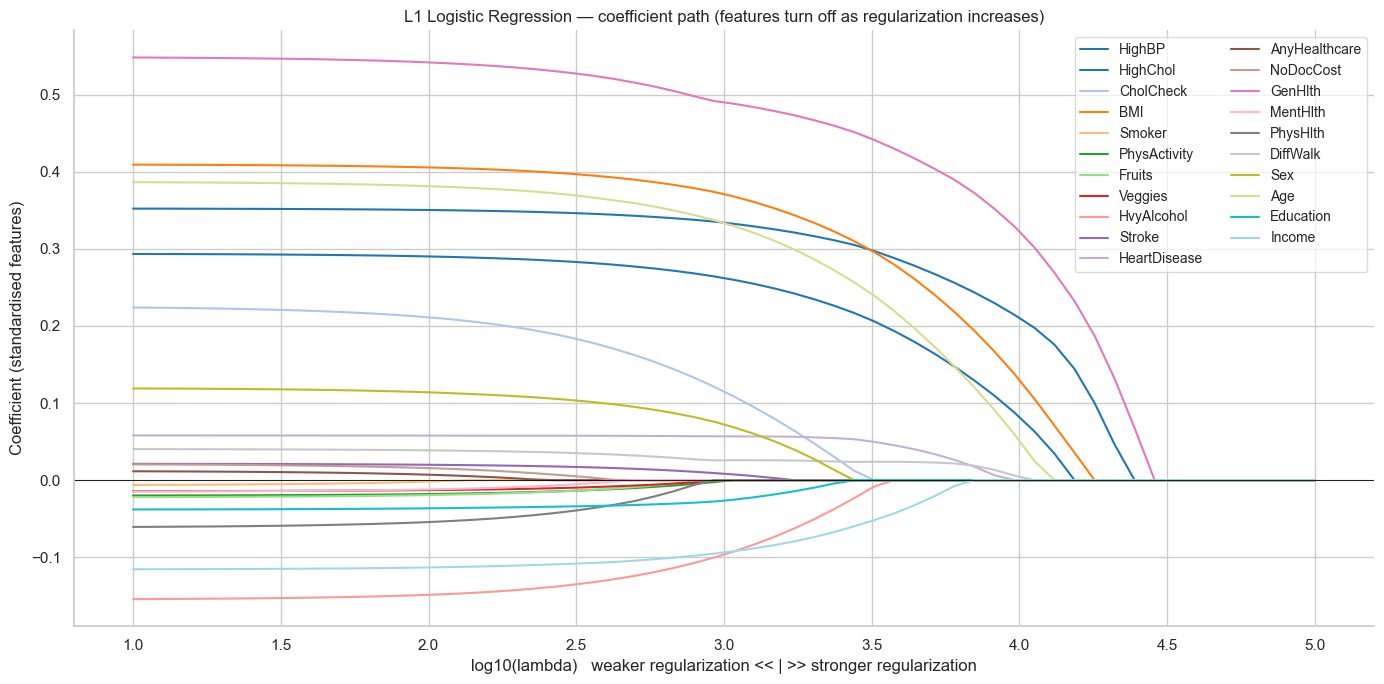

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df[FEATURE_COLS_MODEL].astype(float).values
y = df["Diabetes_binary"].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Range tightened to the elimination region: C from 10^-1 to 10^-5 (log10(lambda) from -1 >> 5)
Cs = np.logspace(-1, -5, 60)
coefs = []
for C in Cs:
    lr = LogisticRegression(penalty="l1", solver="liblinear", C=C, max_iter=1000)
    lr.fit(X_scaled, y)
    coefs.append(lr.coef_[0])

coefs = np.array(coefs)
log_lambda = -np.log10(Cs)
feat_names = [DISPLAY_NAMES.get(c, c) for c in FEATURE_COLS_MODEL]

# Survival order: last position where |coef| > 0.001
survival = {}
for i, name in enumerate(feat_names):
    active = np.where(np.abs(coefs[:, i]) > 0.001)[0]
    survival[name] = log_lambda[active[-1]] if len(active) else log_lambda[0]

survival_order = sorted(survival.items(), key=lambda x: -x[1])
print("Feature survival order (most >> least robust under increasing L1 regularization):")
for rank, (name, lam) in enumerate(survival_order, 1):
    print(f"  {rank:2d}. {name:<20s}  survives until log10(λ) ≈ {lam:.2f}")

cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(14, 7))
for i, name in enumerate(feat_names):
    ax.plot(log_lambda, coefs[:, i], label=name, color=cmap(i / len(feat_names)), linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("log10(lambda)   weaker regularization << | >> stronger regularization")
ax.set_ylabel("Coefficient (standardised features)")
ax.set_title("L1 Logistic Regression — coefficient path (features turn off as regularization increases)", fontsize=12)
ax.legend(loc="upper right", fontsize=10, ncol=2, framealpha=0.7)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_l1_coefficient_path.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "10_l1_coefficient_path.pdf", bbox_inches="tight", dpi=300)
plt.show()

---
## Step 7 — Train/Test Split

Stratified 80/20 split on `Diabetes_binary`. Stratification ensures the class ratio is preserved in both sets — important given the ~84/16 imbalance. The test set is never touched for balancing or resampling; it retains the natural class distribution to give realistic evaluation metrics.

In [59]:
from sklearn.model_selection import train_test_split

X_all = df[FEATURE_COLS_MODEL].astype(float)
y_all = df["Diabetes_binary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=42,
)

print(f"Train : {len(X_train):,} rows  ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test  : {len(X_test):,} rows  ({len(X_test)/len(df)*100:.1f}%)")

train_rate = y_train.mean()
test_rate  = y_test.mean()
print(f"\nDiabetes rate — train : {train_rate:.4f}  ({train_rate*100:.1f}%)")
print(f"Diabetes rate — test  : {test_rate:.4f}  ({test_rate*100:.1f}%)")
print(f"Difference            : {abs(train_rate - test_rate):.4f}")

assert abs(train_rate - test_rate) < 0.01, "Class distribution drift between train and test exceeds 1%"
print("\nAssertion passed — class distributions match within 1%.")

Train : 202,944 rows  (80.0%)
Test  : 50,736 rows  (20.0%)

Diabetes rate — train : 0.1576  (15.8%)
Diabetes rate — test  : 0.1576  (15.8%)
Difference            : 0.0000

Assertion passed — class distributions match within 1%.


---
## Step 8 — Class Imbalance Analysis

We quantify the imbalance on the training set only. The test set is left at its natural distribution throughout — it is never resampled.

Training set class distribution:
  Class 0  No diabetes           : 170,962  (84.2%)
  Class 1  Diabetes/Pre-diabetes : 31,982  (15.8%)

Imbalance ratio (majority / minority) : 5.3x

Modeling strategy:
  • Logistic Regression                  : class_weight='balanced'
  • Neural Network                       : pos_weight in BCEWithLogitsLoss
  • SVM / Kernel methods                 : trained on undersampled set (Step 9)


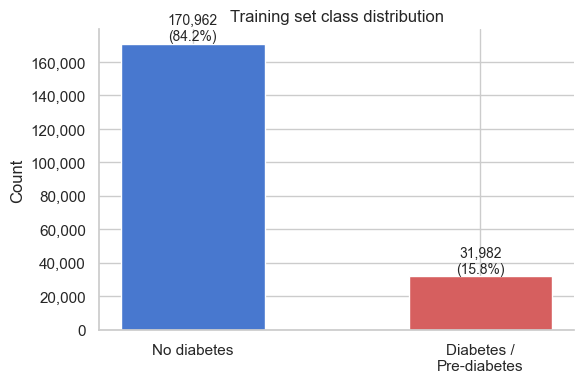

In [60]:
train_counts = y_train.value_counts().sort_index()
train_pcts   = train_counts / train_counts.sum() * 100

print("Training set class distribution:")
for cls, cnt in train_counts.items():
    print(f"  Class {cls}  {'No diabetes' if cls == 0 else 'Diabetes/Pre-diabetes':<22s}: {cnt:,}  ({train_pcts[cls]:.1f}%)")

imbalance_ratio = train_counts[0] / train_counts[1]
print(f"\nImbalance ratio (majority / minority) : {imbalance_ratio:.1f}x")
print(f"\nModeling strategy:")
print(f"  • Logistic Regression                  : class_weight='balanced'")
print(f"  • Neural Network                       : pos_weight in BCEWithLogitsLoss")
print(f"  • SVM / Kernel methods                 : trained on undersampled set (Step 9)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No diabetes", "Diabetes /\nPre-diabetes"], train_counts.values,
              color=["#4878cf", "#d65f5f"], edgecolor="white", width=0.5)
for bar, cnt, pct in zip(bars, train_counts.values, train_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Training set class distribution", fontsize=12)
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_train_class_distribution.png", bbox_inches="tight", dpi=150)
plt.savefig(OUTPUT_DIR / "05_train_class_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()

---
## Step 9 — Undersampling (Training Set Only)

We randomly undersample the majority class in the training set to produce a 50/50 balanced variant. This is used as a ready-made training artifact for SVM and kernel methods, which are sensitive to class imbalance and scale poorly on the full ~200K row training set.

The test set is not touched.

In [61]:
train_df = X_train.copy()
train_df["Diabetes_binary"] = y_train.values

minority_n = (y_train == 1).sum()
majority_downsampled = (
    train_df[train_df["Diabetes_binary"] == 0]
    .sample(n=minority_n, random_state=42)
)
minority = train_df[train_df["Diabetes_binary"] == 1]

train_balanced = (
    pd.concat([majority_downsampled, minority])
    .sample(frac=1, random_state=42)   # shuffle
    .reset_index(drop=True)
)

X_train_bal = train_balanced[FEATURE_COLS_MODEL]
y_train_bal = train_balanced["Diabetes_binary"]

bal_counts = y_train_bal.value_counts().sort_index()
print(f"Balanced training set:")
print(f"  Class 0 (No diabetes)          : {bal_counts[0]:,}")
print(f"  Class 1 (Diabetes/Pre-diabetes): {bal_counts[1]:,}")
print(f"  Total                          : {len(train_balanced):,}")
print(f"  Rows discarded from majority   : {len(train_df) - len(train_balanced):,}")
assert bal_counts[0] == bal_counts[1], "Balanced set is not exactly 50/50"
print("\nAssertion passed — training set is exactly 50/50.")

Balanced training set:
  Class 0 (No diabetes)          : 31,982
  Class 1 (Diabetes/Pre-diabetes): 31,982
  Total                          : 63,964
  Rows discarded from majority   : 138,980

Assertion passed — training set is exactly 50/50.


---
## Step 10 — Export Cleaned Data

All artifacts saved to `data/`. Downstream modeling notebooks load from these files rather than re-running the cleaning pipeline.

| File | Contents | Use |
|---|---|---|
| `clean_2015_full.csv` | All cleaned rows, all features, both target columns | Reference / ad-hoc analysis |
| `train.csv` | 80% stratified split, natural class distribution | LR, Neural Network (use `class_weight='balanced'`) |
| `test.csv` | 20% stratified split, natural class distribution | Evaluation for all models |
| `train_balanced.csv` | Undersampled 50/50 training set | SVM, Kernel methods |

In [62]:
DATA_DIR.mkdir(exist_ok=True)

# Full cleaned dataset
df.to_csv(DATA_DIR / "clean_2015_full.csv", index=False)

# Train / test splits (natural class distribution)
train_out = X_train.copy()
train_out["Diabetes_binary"] = y_train.values
train_out.to_csv(DATA_DIR / "train.csv", index=False)

test_out = X_test.copy()
test_out["Diabetes_binary"] = y_test.values
test_out.to_csv(DATA_DIR / "test.csv", index=False)

# Balanced training set
train_balanced.to_csv(DATA_DIR / "train_balanced.csv", index=False)

# Confirm file sizes
for fname in ["clean_2015_full.csv", "train.csv", "test.csv", "train_balanced.csv"]:
    path = DATA_DIR / fname
    size_mb = path.stat().st_size / 1e6
    rows = sum(1 for _ in open(path)) - 1  # subtract header
    print(f"  {fname:<25s}  {rows:>7,} rows  {size_mb:.1f} MB")

print("\nAll files written successfully.")

  clean_2015_full.csv        253,680 rows  13.3 MB
  train.csv                  202,944 rows  18.0 MB
  test.csv                    50,736 rows  4.5 MB
  train_balanced.csv          63,964 rows  5.7 MB

All files written successfully.
